### hill関数

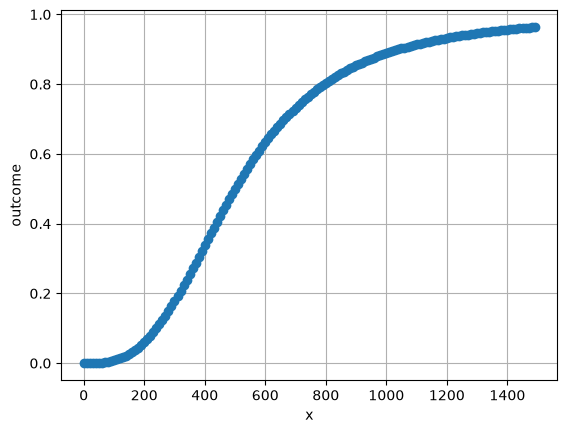

In [ ]:
"""
hill関数の定義

- x : メディア出稿量
- k : 半飽和量
- s : slope
- outcome : 効果量

"""
def hill_func(x:float, k:float, s:float):
    outcome = x**s / (x**s + k**s)
    return x, outcome

#----------------------------------------------------

"""
hill関数のプロット

- par(K)が増加するほど、グラフの立ち上がりが右へずれる
- par(S)が増加するほどpar(K)を起点に勾配が急になる

"""
import matplotlib.pyplot as plt
x_values = []
y_values = []

for x in range(0, 1500, 10):
    x, outcome = hill_func(x=x, k=500, s=3.0)
    x_values.append(x)
    y_values.append(outcome)
    
plt.plot(x_values, y_values, marker="o")
plt.xlabel("x")
plt.ylabel("outcome")
plt.grid(True)
plt.show()

#----------------------------------------------------


### adstock関数

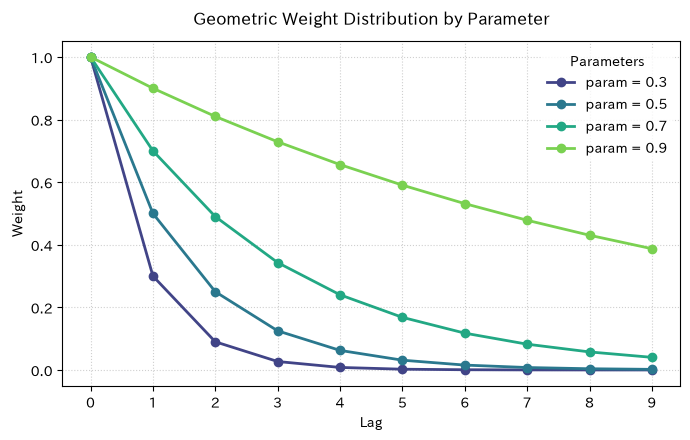

In [20]:
"""
- weight geometric
    w(l) = α^l ; 0<α<1, l=0,...,l-1
"""
#関数定義
#--------------------------------------------------------------------------

def weight_geo(a:float, l:float):
    # 0 〜 1 の範囲に制限
    if not (0 < a < 1):
        raise ValueError(f"aは 0<a<1 で指定してください（入力値: {a}）")
    else:
        return a**l
    
#--------------------------------------------------------------------------
#実測値
#--------------------------------------------------------------------------

import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. 比較したいパラメータとLagの設定
params = [0.3, 0.5, 0.7, 0.9]
lags = list(range(10))

# カラーマップを使って自動で綺麗なグラデーション色を作成
# （または colors = ['blue', 'green', 'orange', 'red'] のように直接指定も可）
colors = plt.cm.viridis([0.2, 0.4, 0.6, 0.8])

# 2. グラフ描画の準備
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)

# 3. ループ処理で計算と描画をまとめて実行
for p, color in zip(params, colors):
    # パラメータごとに weight を計算
    weights = [weight_geo(p, l) for l in lags]
    
    # グラフを描画（labelにパラメータ値を埋め込む）
    ax.plot(lags, weights, marker='o', color=color, linewidth=2, 
            label=f'param = {p}')

# 4. 装飾設定
ax.set_title('Geometric Weight Distribution by Parameter', fontsize=12, pad=12)
ax.set_xlabel('Lag', fontsize=10)
ax.set_ylabel('Weight', fontsize=10)

# X軸の目盛りを整数（0~9）に固定
ax.set_xticks(lags)

# グリッド線を薄く描画
ax.grid(True, linestyle=':', alpha=0.6)

# 凡例の設定（グラフの外側や分かりやすい場所に配置）
ax.legend(title='Parameters', frameon=True, facecolor='white', edgecolor='none')

# レイアウト調整
plt.tight_layout()
plt.show()

#--------------------------------------------------------------------------

### θを変化させたときの重みづけ関数

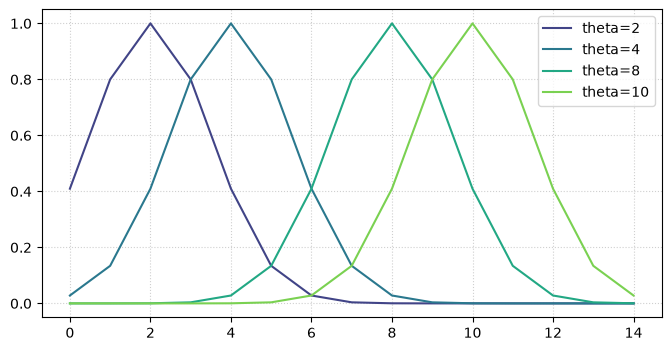

In [3]:
#関数定義
#-----------------------------------------------------
from typing import List

def weight_delay(alpha: float, theta: float, l: int) -> float:
    """
    条件:
      - 0 < alpha < 1
      - 0 <= theta <= L - 1
      - l = 0, ..., L-1
    """
    # 1. 引数の範囲・条件判定 (条件外ならValueError)
    if not (0 < alpha < 1):
        raise ValueError(f"alpha は 0 < alpha < 1 である必要があります (指定された値: {alpha})")

    # 2. l = 0, ..., L-1 に対して重みを計算
    # ※ 数式が (l - theta)**2 の場合を想定
    weights = alpha ** ((l - theta) ** 2)
    
    return weights

#実測値    
#-----------------------------------------------------
lags = list(range(15))
"""
- thetaを変化させた場合
- L=10, alpha=0.7
"""
par_theta = [2, 4, 8, 10]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
colors = plt.cm.viridis([0.2, 0.4, 0.6, 0.8])

for p, col in zip(par_theta, colors):
    weights = [weight_delay(0.8, p, l) for l in lags]
    ax.plot(lags, weights, color=col, label=f"theta={p}")

# グリッド線を薄く描画
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()
plt.show()


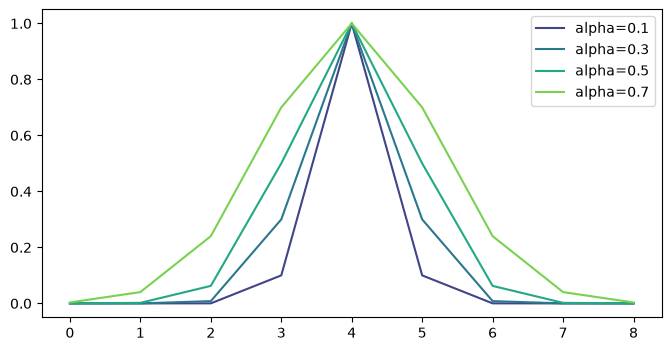

In [10]:
lags = list(range(9))

"""
- alphaを変化させた場合
- L=10, theta=5
"""

import matplotlib.pyplot as plt

par_alpha = (0.1, 0.3, 0.5, 0.7)
colors = plt.cm.viridis([0.2, 0.4, 0.6, 0.8])

fig, ax = plt.subplots(figsize=(8,4))

for alpha, col in zip(par_alpha, colors):
    weights = []
    weights = [weight_delay(alpha, 4, l) for l in lags]
    ax.plot(lags, weights, color=col, label=f"alpha={alpha}")

plt.legend()
plt.show()


In [22]:
import pandas as pd

df = pd.DataFrame({'country':['japan', 'russian', 'germany'],
                   'pop':[1000, 2000, 3000]}).assign(
                       pop2 = lambda x:x['pop']+1000)
df

,country,pop,pop2
0,japan,1000,2000
1,russian,2000,3000
2,germany,3000,4000
